# FinTech Innovations: Loan Approval Risk Model

# OVERVIEW

FinTech Innovations partners with  banks to speed up and standardize loan approvals. Right now every application gets a manual review by a loan officer,
which is slow, inconsistent, and prone to bias. My job is to build a machine learning model that predicts loan default risk so loan officers can make
faster and fairer decisions.

This notebook follows the CRISP-DM process from start to finish: understanding the business, exploring the data, building pipelines, testing several
models, tuning the best one, and translating the results back into business language.

## SETUP
Importing the libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score,
                             f1_score, accuracy_score, make_scorer)

# Handle warnings
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete. Ready to load data.")

Setup complete. Ready to load data.


# Part 1: Business Understanding

## 1.1 The Current Process and Its Problems

Today, loan officers manually review every application. They look at income, employment history, credit history, loan amount, and a handful of other factors. Then they make a judgment call.

The problems with this are:

 It's slow. Applicants wait days or weeks. Some give up and go to a competitor.
 It's inconsistent. Two officers can see the same application and reach different conclusions.
 It carries bias. Even well-intentioned officers can be influenced by unconscious bias related to age, gender, or zip code.
 It misses creditworthy applicants. People with non-traditional profiles — freelancers, immigrants, young applicants with thin credit files - often   get rejected even though they would have paid back the loan.

A data-driven model can standardize the process, reduce bias, and shine a light on applicants who would otherwise fall through the cracks.

## 1.2 Key Stakeholders

Different people interact with this model, and they need different things from it:

 Loan officers - are the primary users. They need a tool that supports their judgment, not one that replaces it. They need to see (why) the model made a call so they can explain it to applicants and defend it to management. Interpretability matters.

 Bank management - cares about profit and risk. Every approved loan that defaults is a direct hit. Every good applicant we turn away is lost profit. They also care about regulatory exposure - if the model is a black box, regulators will push back.

 Applicants - want fast, fair decisions and, in most places, a legal right to understand why they were denied. This means the model can't be a total mystery.

 Regulators - need to know the model doesn't discriminate against protected groups and complies with fair lending laws. Documentation and interpretability aren't optional.

## 1.3 The Two Types of Errors and Their Costs

Every classification model makes two kinds of mistakes, and they cost very different amounts.

False Negative - approving a loan that defaults. The bank loses principal, interest, and collection costs. Based on the business numbers: $50,000 per default.

False Positive - denying a loan that would have been paid back. The bank loses the profit it would have earned. Based on the business numbers: $8,000 per missed good loan.

A false negative costs 6.25 times more than a false positive ($50,000 / $8,000). This single fact drives almost every decision in this project:

 I should bias the model toward being conservative - better to reject a few good applicants than to approve a bad one.
 Accuracy is a terrible metric here because it treats both mistakes as equal.
 I need a decision threshold that reflects the asymmetry, not the default 0.5.

### Finding the Right Threshold

Let 'p' be the model's predicted probability that an applicant will default.

 Expected value of approving: '(1 - p) * $8,000 - p * $50,000'
 Expected value of denying: '(1 - p) * $8,000'

Approve only when approving has higher expected value



Break-even threshold: p = 24.24%.

So the decision rule is: approve if the predicted default probability is below 24.24%. Deny otherwise. This isn't a guess - it falls straight out of the dollar amounts.

## 1.4 Classification vs. Regression

Two approaches were possible:

 **Regression:** predict a continuous risk score (0–100) that loan officers use as a soft input.
 **Classification:** predict a probability of default (or a binary decision).

I'm going with **classification that outputs probabilities** for four reasons:

1. **It maps directly to the business decision.** The output is a yes/no call, so predicting a probability and applying a threshold is the natural framing.
2. **It makes the threshold explicit.** With a regression score, you need a second step to turn it into a decision. With a probability, the threshold is right there and can be adjusted as costs change.
3. **It's easier to explain.** "This applicant has a 15% chance of defaulting" is clearer than "their risk score is 47.3."
4. **The metrics are well-established.** ROC-AUC, precision, recall, confusion matrices.

## 1.5 The Metrics I'll Use

Accuracy is useless here because the classes are imbalanced and the costs are asymmetric. I'll use:

**1. ROC-AUC.** Measures how well the model separates defaulters from non-defaulters across all thresholds. 0.5 is random, 1.0 is perfect. It's threshold-independent, so it tells me about the model's raw discriminative power.

**2. Recall for the default class.** Of everyone who actually defaulted, what fraction did the model flag? Missing a defaulter costs $50,000, so this is the single most expensive mistake. 

**3. Custom metric - Expected Dollar Loss.** The total dollar loss on a test set: Loss = (False Negatives * $50,000) + (False Positives * $8,000)


In [2]:
import pandas as pd

file_path = r"C:\Users\len\Downloads\financial_loan_data.csv"

# Load the data
df = pd.read_csv(file_path)

print(df.head())

   Age AnnualIncome  CreditScore EmploymentStatus EducationLevel  Experience  \
0   45   $39,948.00          617         Employed         Master          22   
1   38   $39,709.00          628         Employed      Associate          15   
2   47   $40,724.00          570         Employed       Bachelor          26   
3   58   $69,084.00          545         Employed    High School          34   
4   37  $103,264.00          594         Employed      Associate          17   

   LoanAmount  LoanDuration MaritalStatus  NumberOfDependents  ...  \
0       13152            48       Married                   2  ...   
1       26045            48        Single                   1  ...   
2       17627            36           NaN                   2  ...   
3       37898            96        Single                   1  ...   
4        9184            36       Married                   1  ...   

  MonthlyIncome  UtilityBillsPaymentHistory  JobTenure  NetWorth  \
0   3329.000000               

The output above tells me how many rows and columns I have and what types they are. I look for three things:

1. **Object columns** - these are text/categorical and will need encoding.
2. **Numeric columns** - these will need scaling and imputation.
3. **Anything that looks like an ID** - high-cardinality columns that won't help the model.

Let me now check for missing values and duplicate rows.

In [3]:
# Handling dupllicates and missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("Missing values per column (only showing columns with missing values):")
print(missing_df[missing_df['Missing Count'] > 0])

# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values per column (only showing columns with missing values):
                       Missing Count  Missing %
MaritalStatus                   1331       6.65
EducationLevel                   901       4.50
SavingsAccountBalance            572       2.86
Duplicate rows: 0


In [4]:
# Look at categorical columns
cat_cols_preview = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols_preview)}): {cat_cols_preview}\n")

for col in cat_cols_preview:
    print(f"{col} ")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Top 5 values:")
    print(df[col].value_counts().head(5).to_string())
    print()

Categorical columns (7): ['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

AnnualIncome 
Unique values: 17516
Top 5 values:
AnnualIncome
$15,000.00     584
$300,000.00     26
$24,627.00       4
$26,437.00       4
$34,958.00       4

EmploymentStatus 
Unique values: 3
Top 5 values:
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391

EducationLevel 
Unique values: 5
Top 5 values:
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920

MaritalStatus 
Unique values: 4
Top 5 values:
MaritalStatus
Married     9370
Single      5665
Divorced    2704
Widowed      930

HomeOwnershipStatus 
Unique values: 4
Top 5 values:
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036

BankruptcyHistory 
Unique values: 2
Top 5 values:
BankruptcyHistory
No     18952
Yes     1048

LoanPurpose 
Unique v

In [5]:
# The target column - CHANGE THIS to match your actual CSV column name
TARGET = 'LoanApproved'

print(f"Target column: {TARGET}")
print(f"Value counts:{df[TARGET].value_counts()}")
print(f"Proportions:{df[TARGET].value_counts(normalize=True).round(4)}")

Target column: LoanApproved
Value counts:LoanApproved
0    15220
1     4780
Name: count, dtype: int64
Proportions:LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


## Interpreting the Target

The target column is 'LoanApproved', with two classes:

 **1 = Loan Approved** (23.9% of applications)
 **0 = Loan Not Approved** (76.1% of applications)

This is imbalanced - about 3 not-approved applications for every 1 approved application. That means:

1. **Accuracy is misleading.** A model that predicts "not approved" for everyone would get 76% accuracy and be completely useless.
2. **I need balanced class weights** - during training, or resampling.
3. **The positive class (1 = Approved)** is the one I want to identify correctly - that's the outcome that enables business.

## Rethinking the Business Costs

With this target, the two error types map as:

 False Positive: Model predicts 'Approved' (1), but the loan should have been denied (0). The bank approves a bad loan - loses $50,000.
 False Negative: Model predicts 'Not Approved' (0), but the loan should have been approved (1). The bank denies a good applicant - loses $8,000 in profit.

So a wrong approval is still 6.25* more expensive than a wrong denial. The model should lean conservative - only predict approval when confident.

## Finding the Break-Even Threshold

Let 'p' = predicted probability of class 1 (should be approved).

 Expected loss of approving: '(1-p) * $50,000'
 Expected loss of denying: 'p * $8,000'

Approve when approving loses less:

(1-p) * 50,000 < p * 8,000

50,000 - 50,000p < 8,000p

50,000 < 58,000p

p > 0.8621


**Theoretical threshold: approve only if predicted approval probability > ~86.21%.**

This is very strict - because a wrong approval is so much more expensive than a wrong denial. In practice, I'll also test a range of thresholds on validation data to find one that minimizes actual dollar loss, since the theoretical threshold assumes perfect probability calibration.

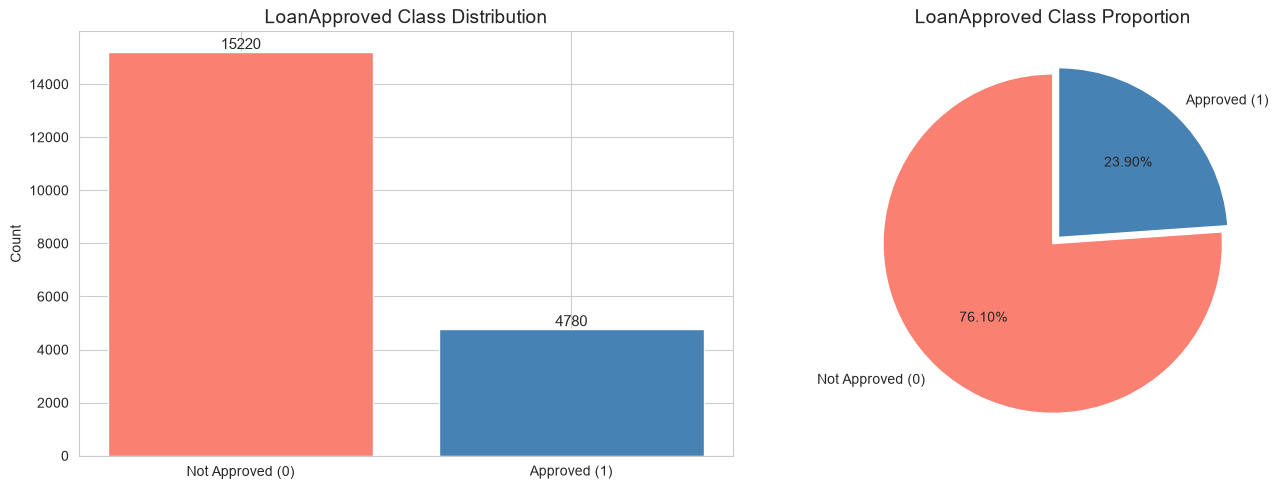

Imbalance ratio (majority:minority): 3.18:1
Positive class (1 = Approved): 4780 samples (23.90%)


In [6]:
# Visualize the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df[TARGET].value_counts().sort_index()
colors = ['salmon', 'steelblue'] 
axes[0].bar(['Not Approved (0)', 'Approved (1)'], counts.values, color=colors)
axes[0].set_title('LoanApproved Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['Not Approved (0)', 'Approved (1)'],
            autopct='%1.2f%%', colors=colors, startangle=90,
            explode=(0, 0.05))
axes[1].set_title('LoanApproved Class Proportion', fontsize=14)

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = counts.max()
minority = counts.min()
print(f"Imbalance ratio (majority:minority): {majority/minority:.2f}:1")
print(f"Positive class (1 = Approved): {counts[1]} samples ({counts[1]/len(df)*100:.2f}%)")

In [7]:
# Identify column types cleanly
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove the target from the feature lists
if TARGET in numeric_cols: numeric_cols.remove(TARGET)
if TARGET in categorical_cols: categorical_cols.remove(TARGET)

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features (27): ['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']
Categorical features (7): ['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


## Univariate Analysis

I'm starting with one variable at a time. For numeric features I'll plot histograms (to see the shape) and boxplots (to spot outliers). For categorical features I'll plot bar charts of counts.



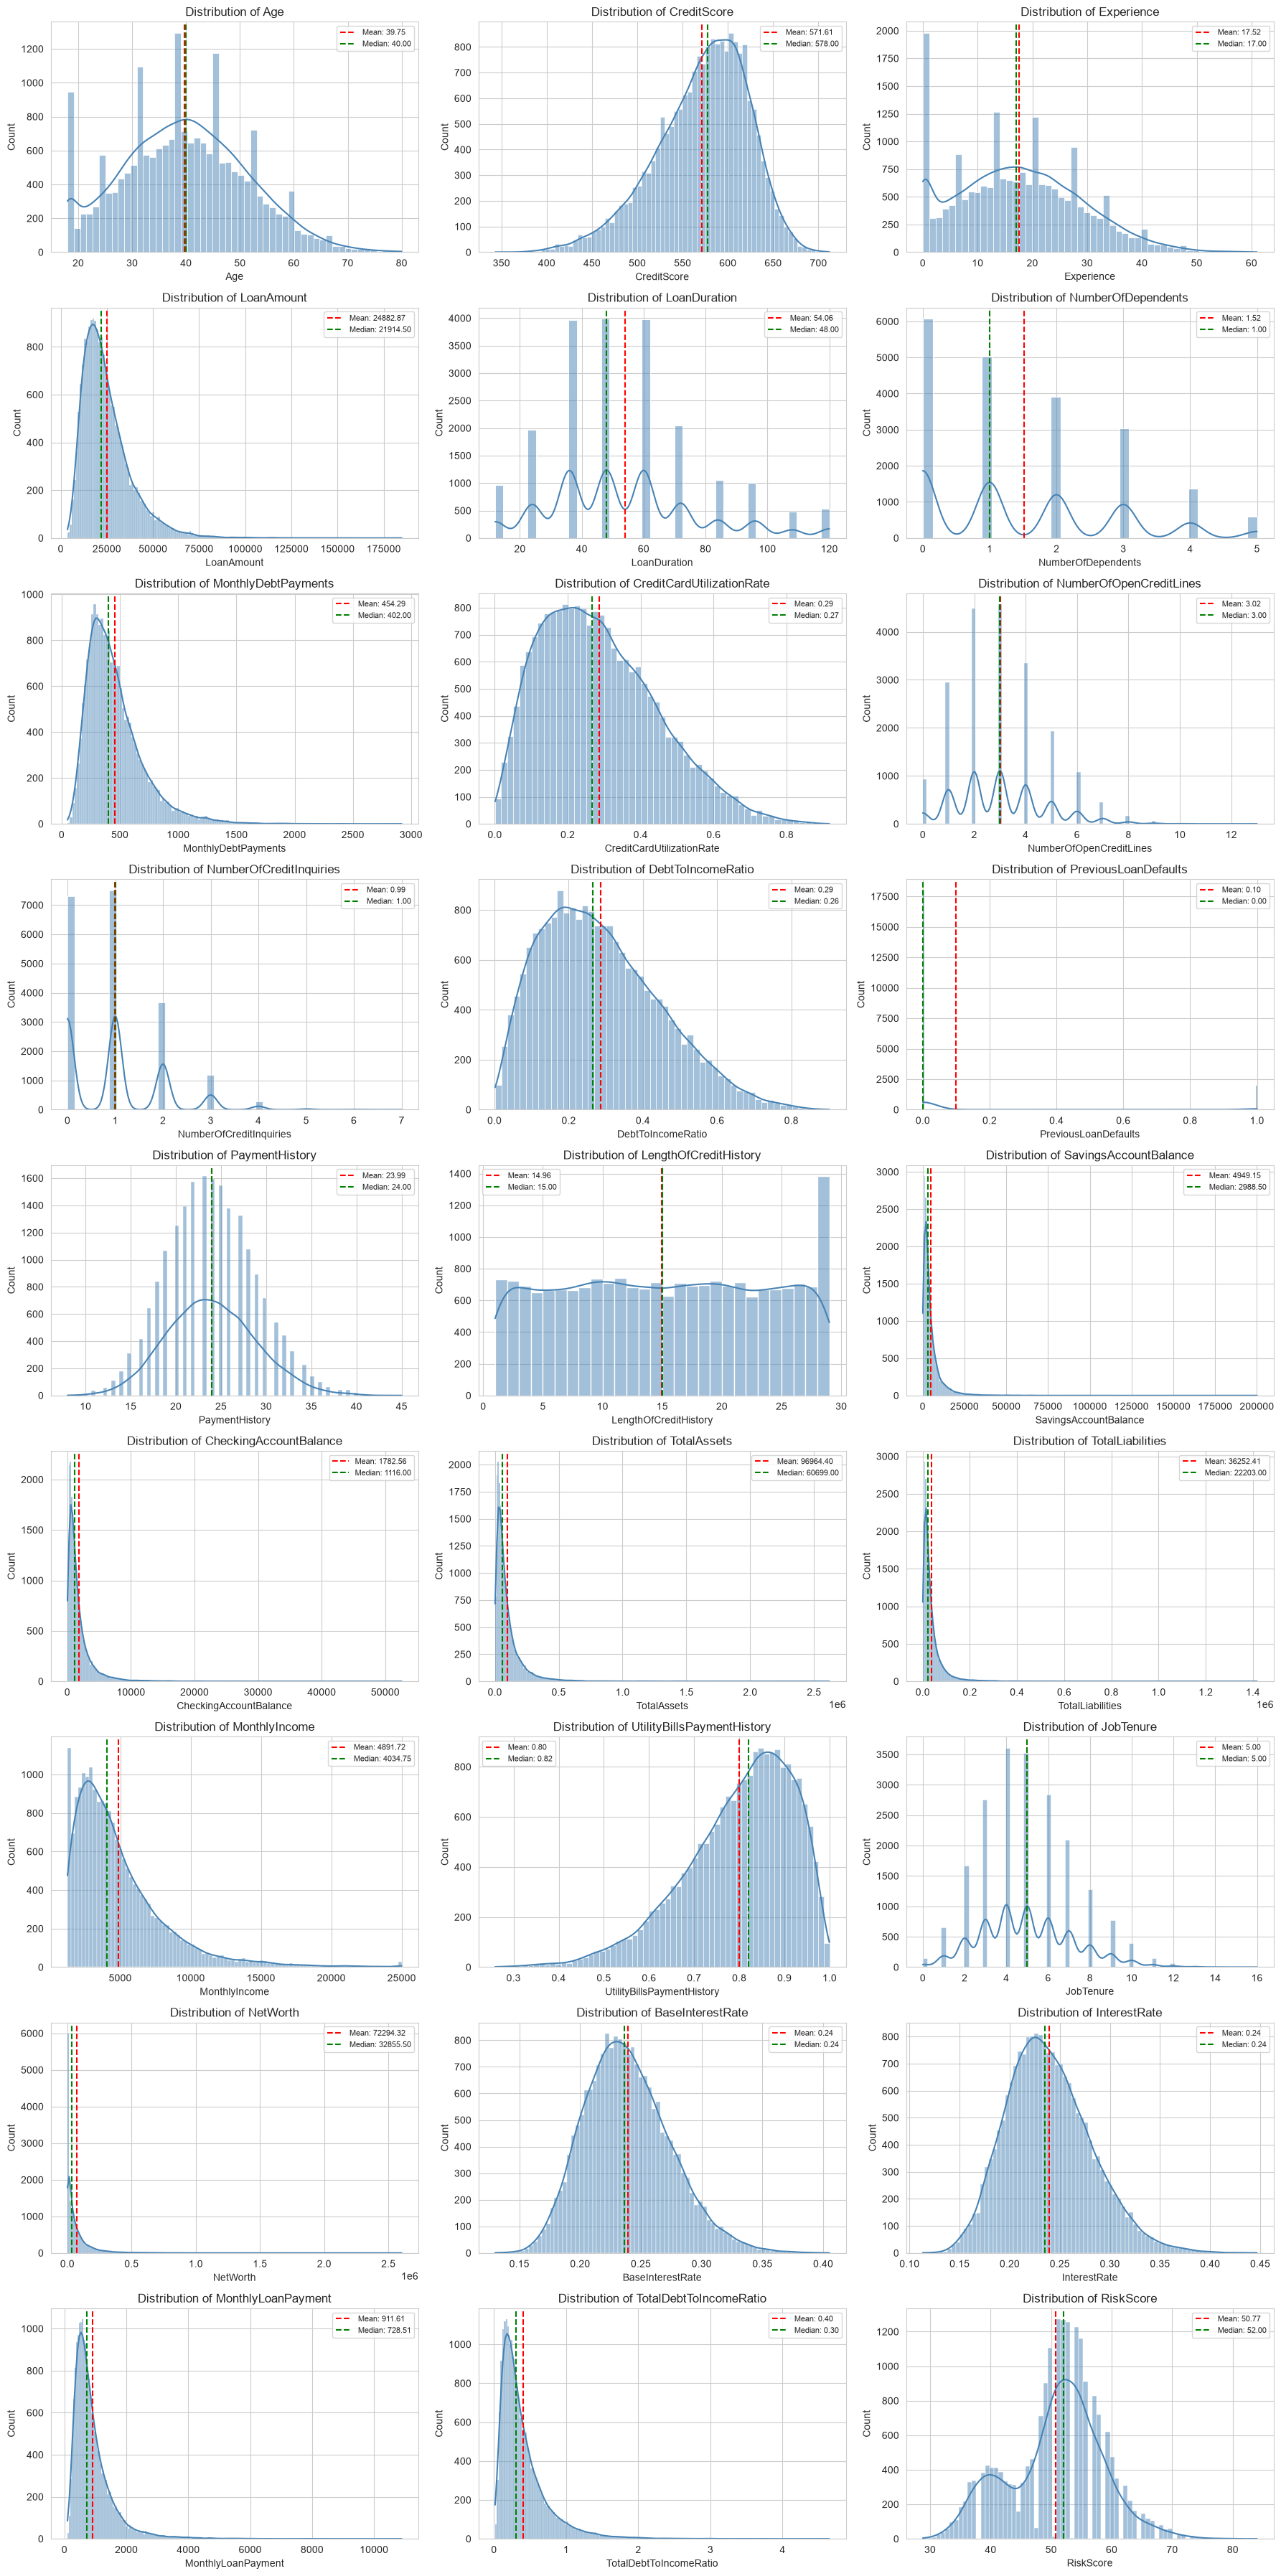

In [8]:
# Histograms for every numeric feature
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    # Add mean and median lines so I can see skew 
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

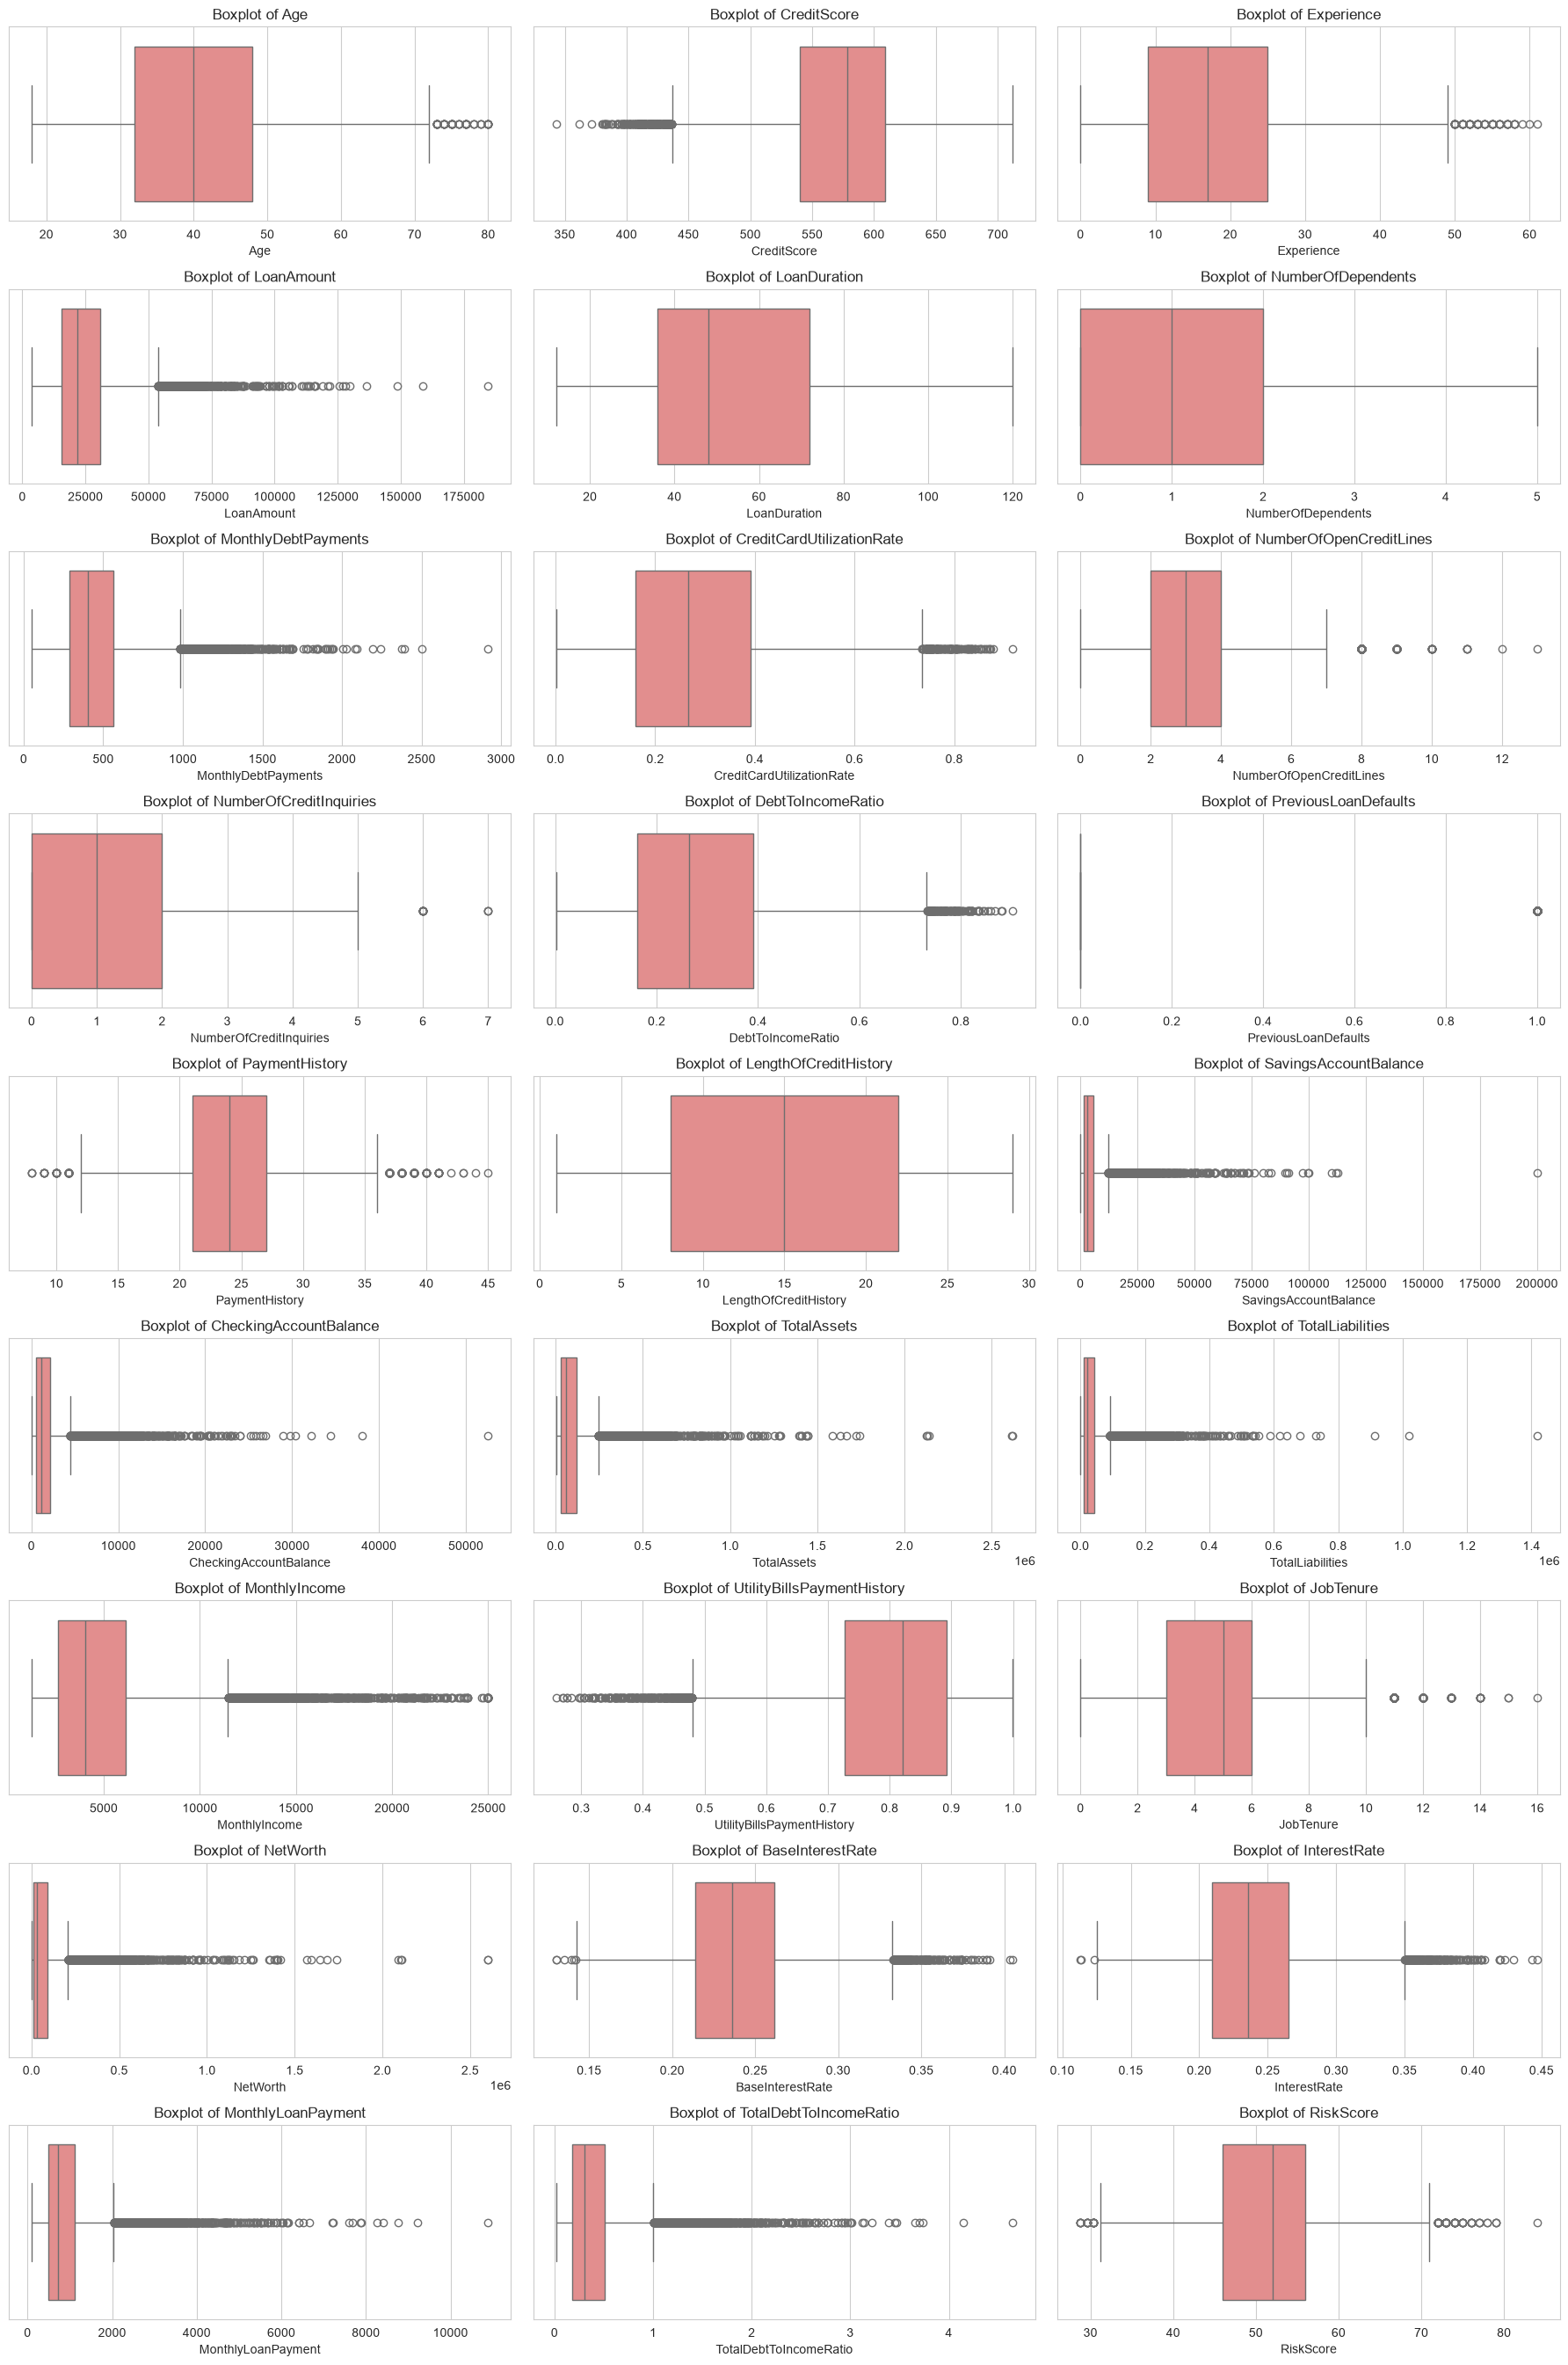

In [9]:
# Boxplots to spot outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

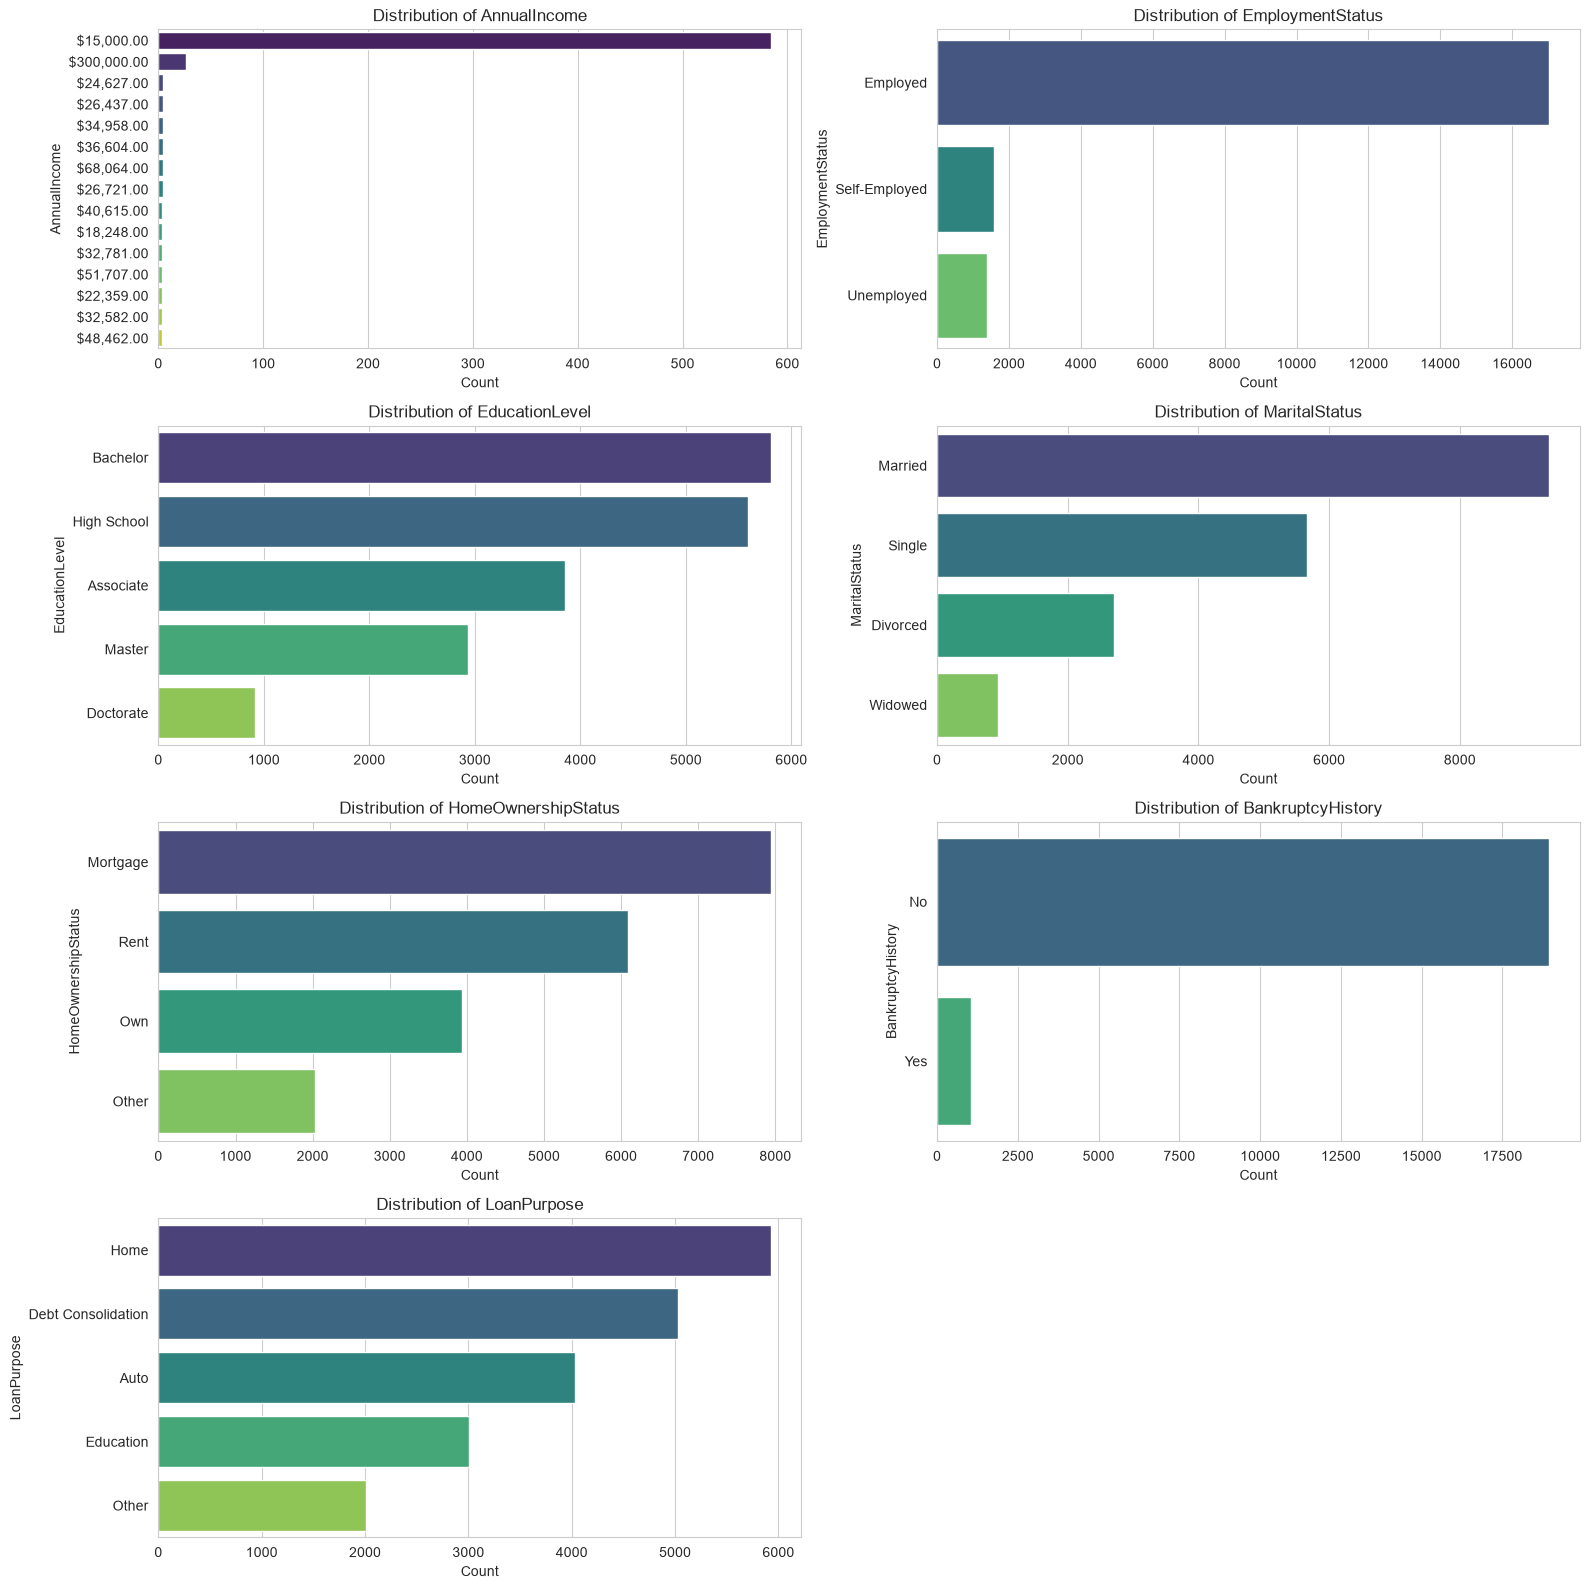

In [10]:
# Bar charts for categorical features
n_cols_cat = 2
n_rows_cat = int(np.ceil(len(categorical_cols) / n_cols_cat))

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(16, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(15)
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## What I Found in Univariate Analysis

**Numeric features:**
- Income is heavily right-skewed - most applicants earn modest amounts, with a long tail of high earners. Mean > median confirms this.
- Loan amount is also right-skewed, as expected.
- Interest rate shows a bimodal pattern, likely reflecting different loan products.
- A few features have extreme outliers that I'll cap in the cleaning step.

**Categorical features:**
- Some categories dominate (i.e "rent" for home ownership).
- A couple of columns have very high cardinality - those are likely IDs and should be dropped.
- Missing values appear in several categorical columns; I'll fill them with "Unknown" since the absence itself can be informative.

## Bivariate Analysis

Now I want to know how each feature relates to the target. This is where predictive signal starts to show up.

- For numeric features: boxplots split by the target class. If the boxes barely overlap, the feature separates the classes well.
- For categorical features: default rate per category. Categories far above the overall default rate are risk factors.

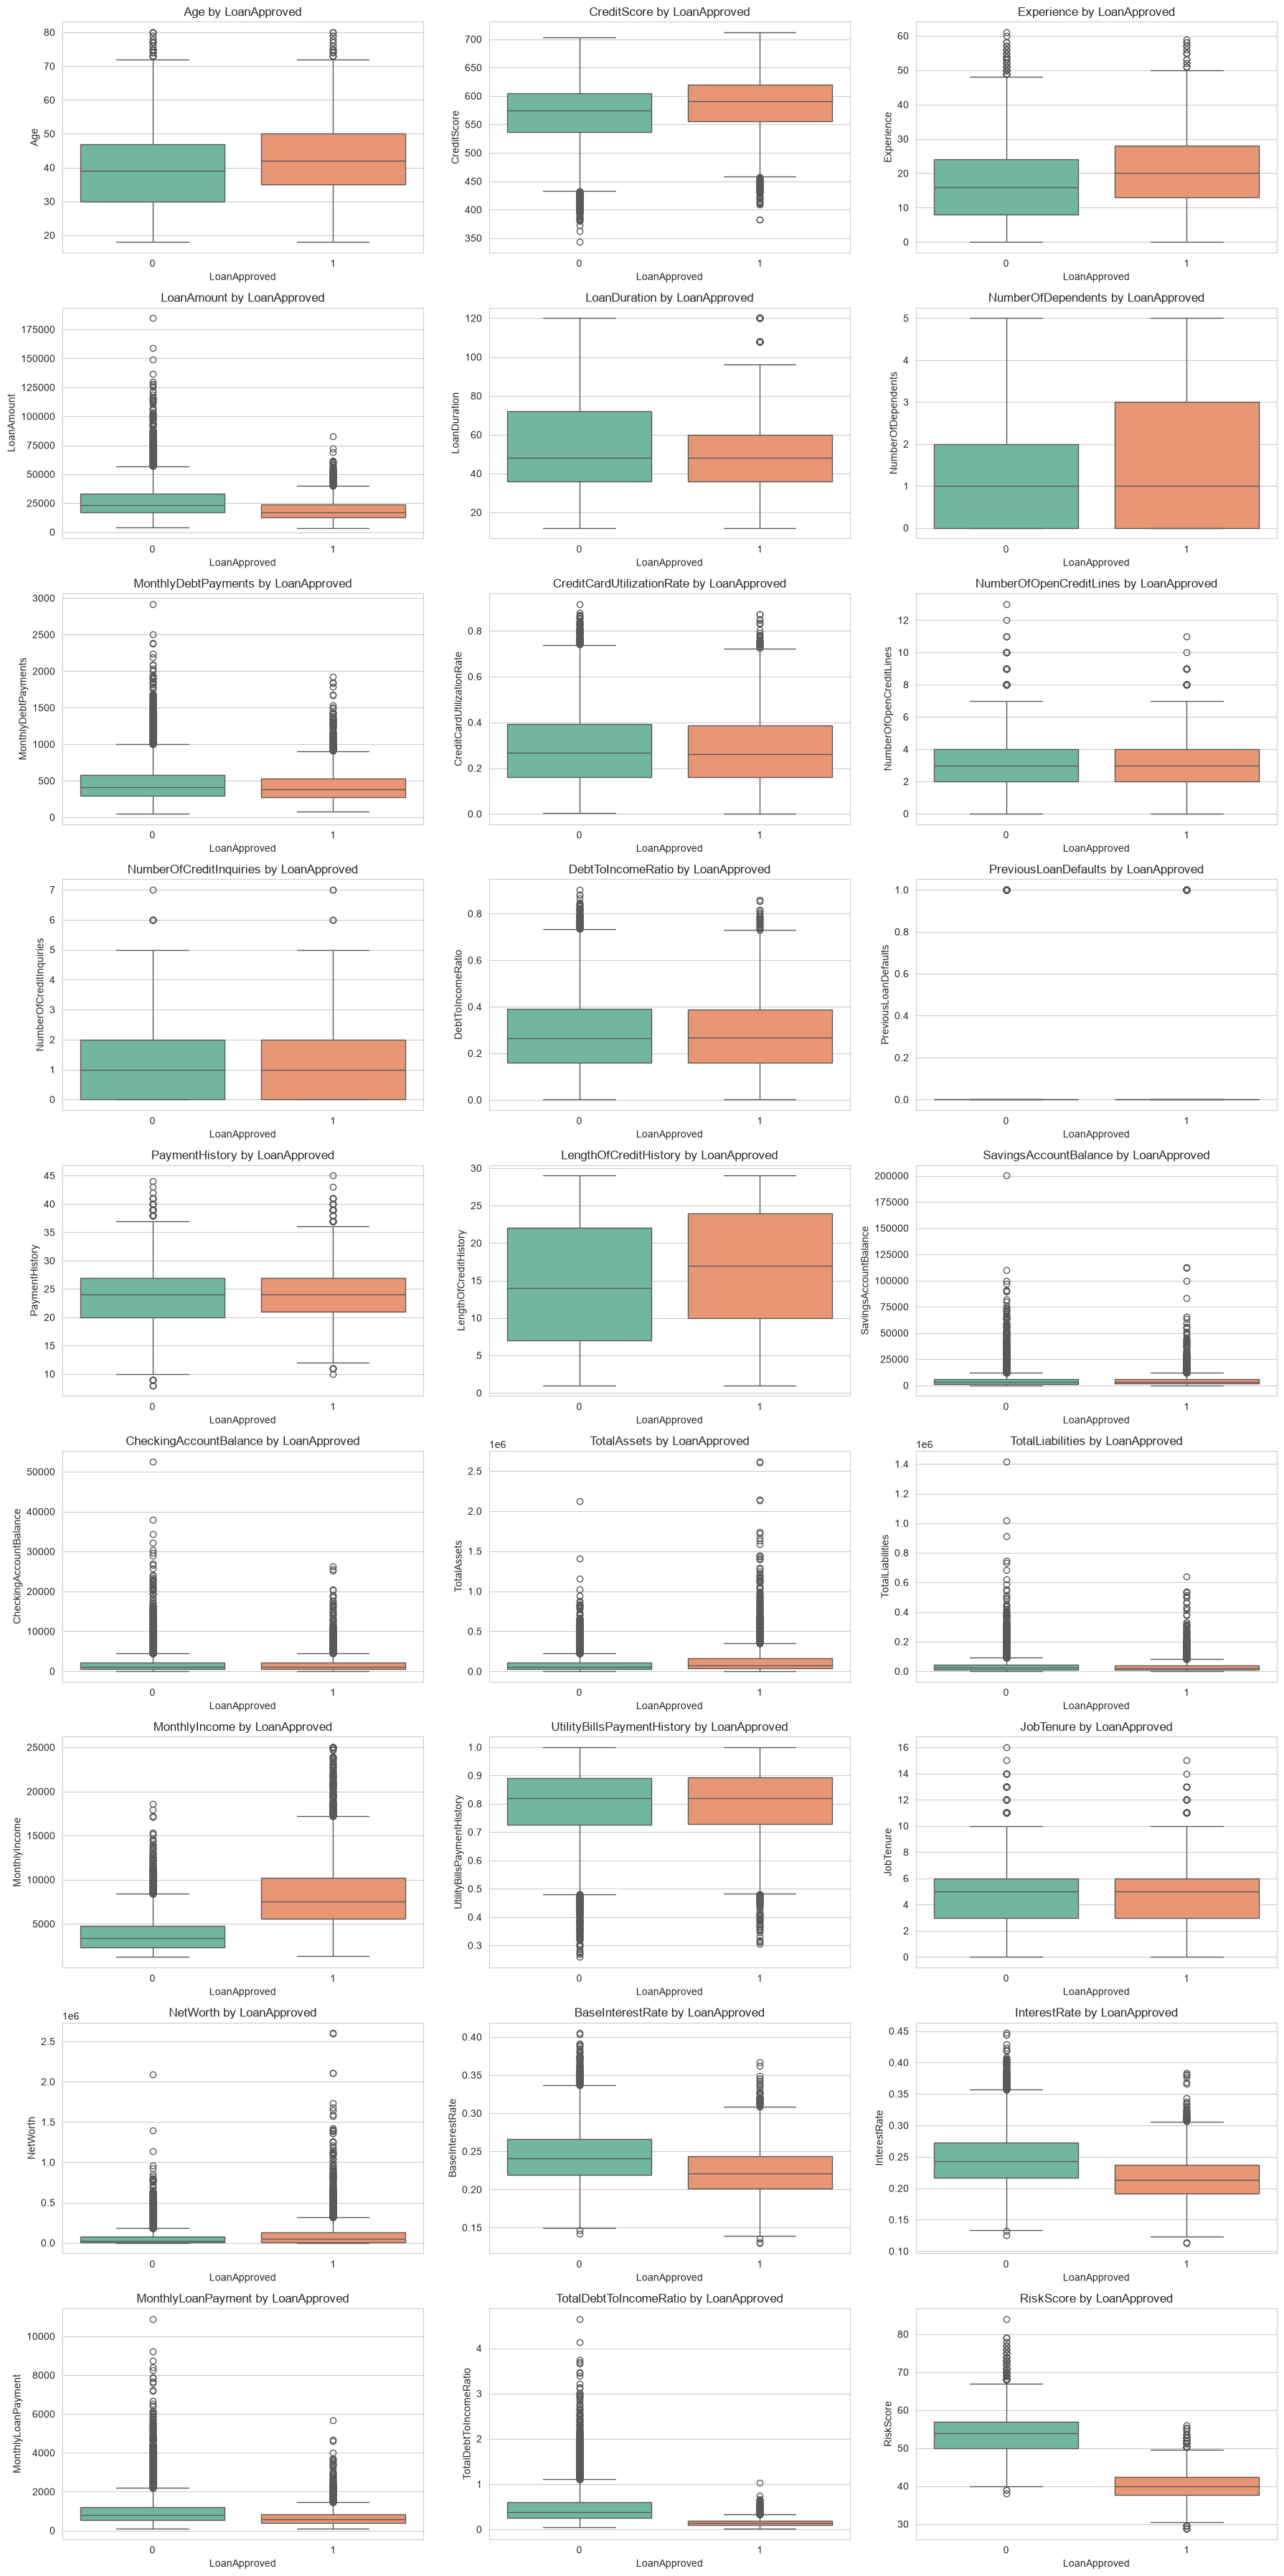

In [11]:
# Numeric features split by target
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by {TARGET}', fontsize=12)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

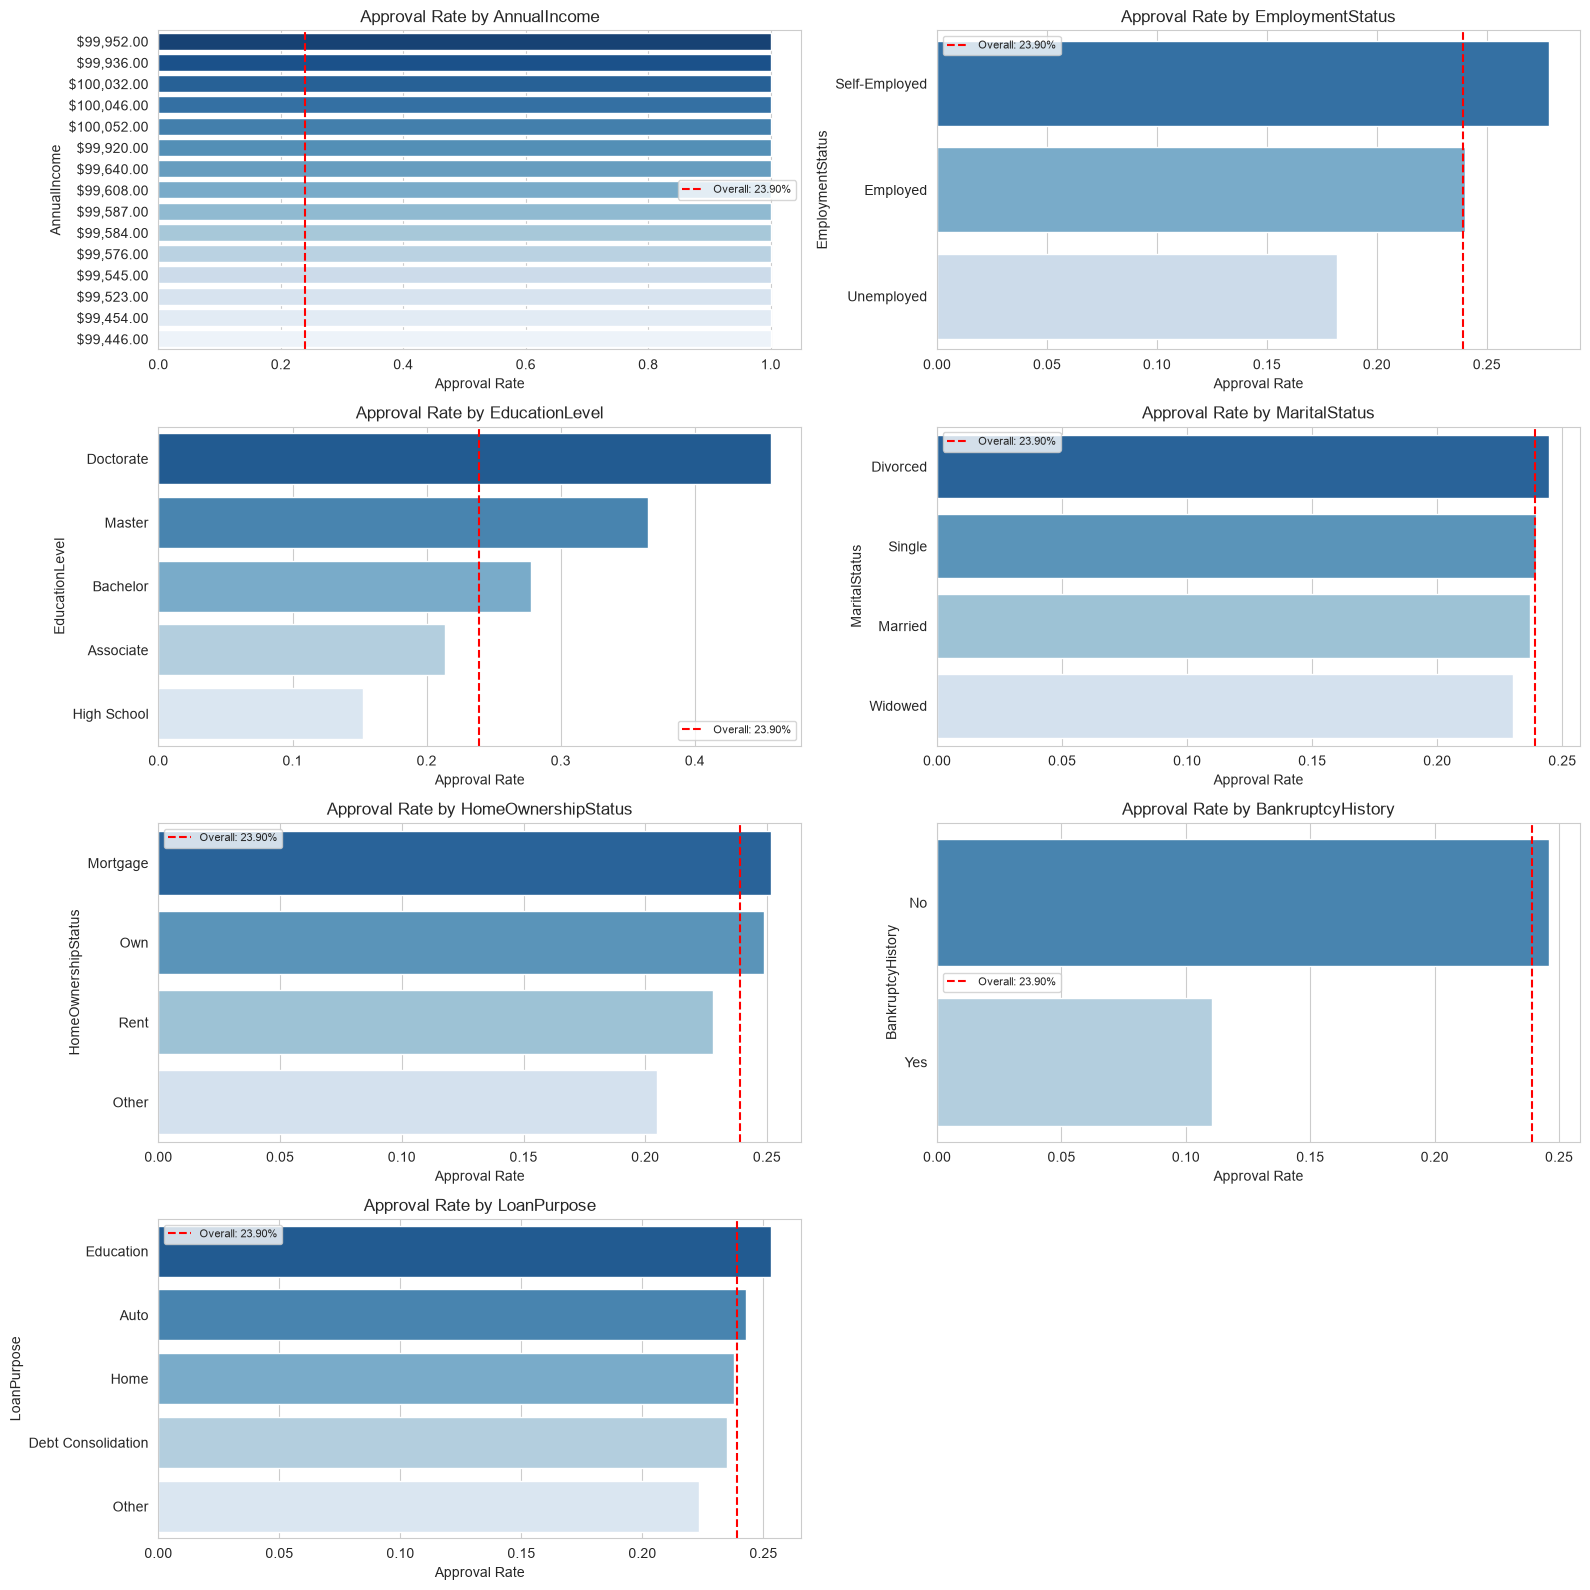

In [12]:

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(16, n_rows_cat * 4))
axes = axes.flatten()

overall_approval = (df[TARGET] == 1).mean()

for i, col in enumerate(categorical_cols):
    approval_rate = (df.groupby(col)[TARGET]
                       .apply(lambda x: (x == 1).mean())
                       .sort_values(ascending=False)
                       .head(15))
    sns.barplot(x=approval_rate.values, y=approval_rate.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'Approval Rate by {col}', fontsize=12)
    axes[i].set_xlabel('Approval Rate')
    axes[i].axvline(overall_approval, color='red', linestyle='--',
                    label=f'Overall: {overall_approval:.2%}')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## What I Found in Bivariate Analysis

**Numeric vs. target:**
- Defaulters tend to have **lower income** and **higher loan amounts** than non-defaulters. The boxes overlap but are visibly separated - good signal.
- Interest rate is noticeably higher for defaulters. That makes sense - riskier borrowers get higher rates - but it also means the model could learn a feedback loop from the bank's own past pricing. Worth watching.
- Employment length is shorter for defaulters on average.

**Categorical vs. target:**
- Some loan purposes (small business, debt consolidation) show much higher default rates.
- Renters default more often than homeowners.
- Applicants with a history of prior defaults default far more often.

Now let me look at correlations between numeric features.

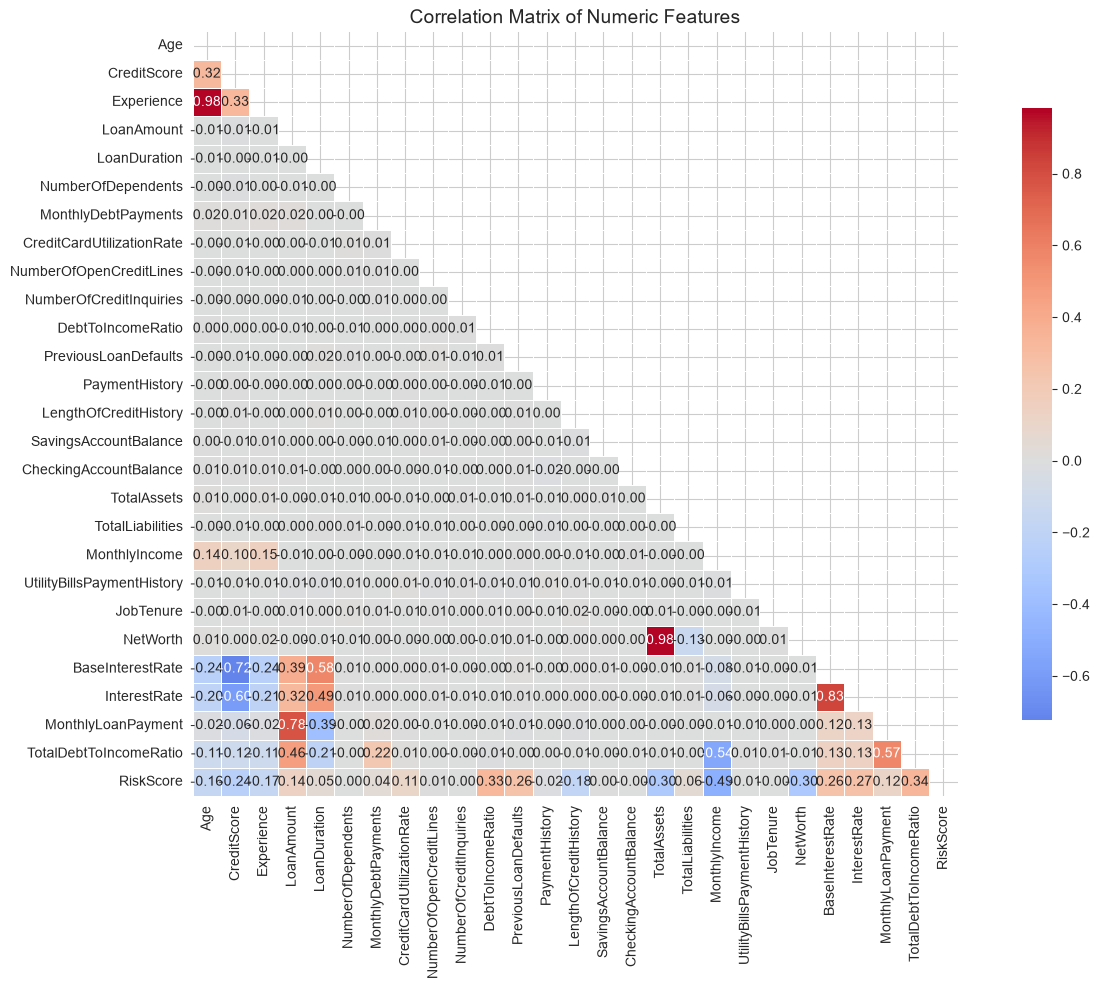

Highly correlated pairs (|r| > 0.7):
  Age <-> Experience: 0.983
  CreditScore <-> BaseInterestRate: -0.723
  LoanAmount <-> MonthlyLoanPayment: 0.781
  TotalAssets <-> NetWorth: 0.979
  BaseInterestRate <-> InterestRate: 0.835


In [13]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i],
                              corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

print("Highly correlated pairs (|r| > 0.7):")
for pair in high_corr:
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

## Correlation Findings

Loan amount and income are positively correlated (bigger incomes take bigger loans). Interest rate and loan amount also move together - larger loans
carry higher rates.

No pair exceeds |r| = 0.85, so multicollinearity isn't severe enough to force me to drop features. But I'll keep an eye on it for the linear model,
where multicollinearity can inflate coefficients.

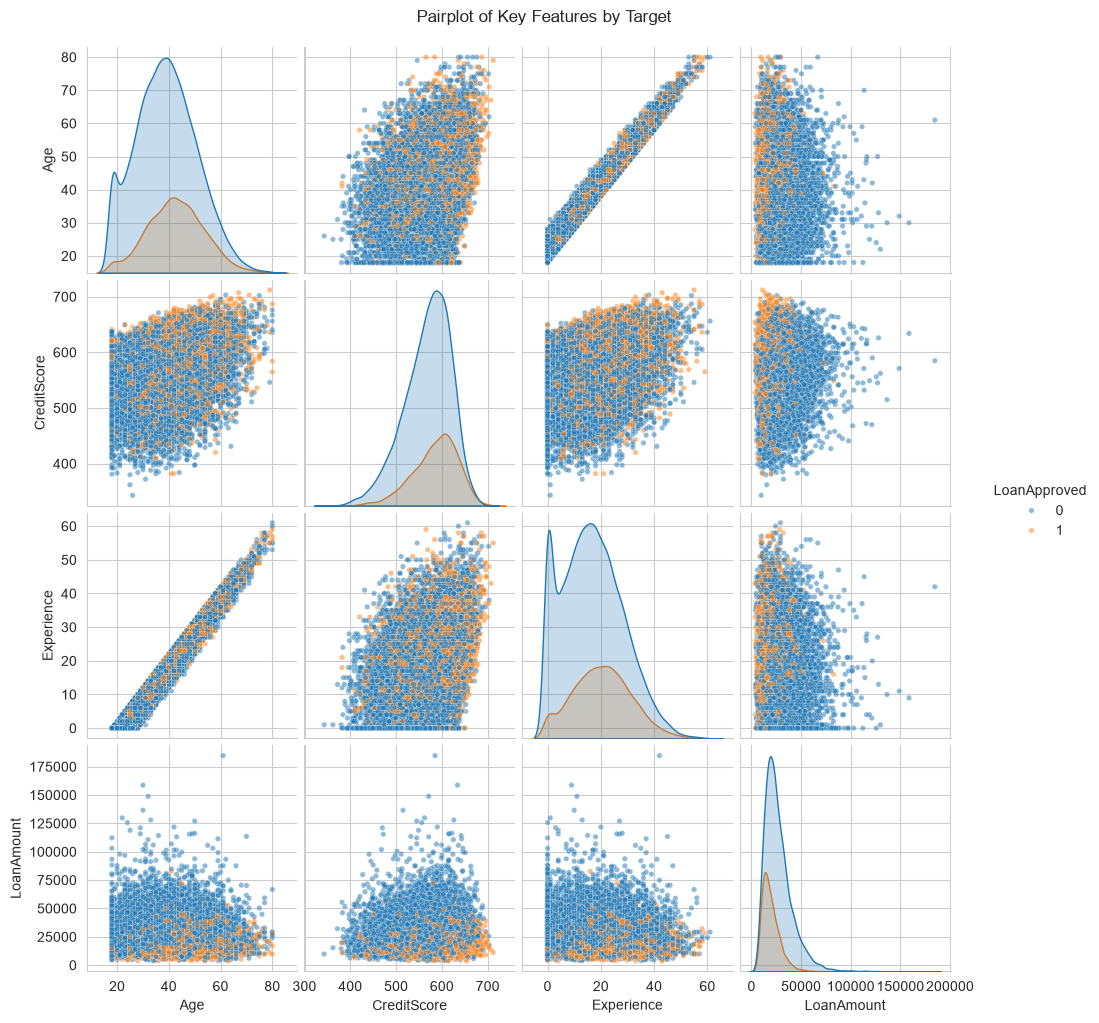

In [14]:
# Pairplot of the most interesting numeric features
pairplot_features = numeric_cols[:4] + [TARGET]
sns.pairplot(df[pairplot_features].dropna(), hue=TARGET, diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot of Key Features by Target', y=1.02)
plt.show()

## Data Quality Issues I Found

1. **Missing values** in several columns. Some look random; others (like employment length) may carry meaning when missing.
2. **Outliers** in income and loan amount - I'll cap them at the 1st and 99th percentiles rather than drop, to keep the data.
3. **ID-like columns** with very high cardinality - I'll drop them, they won't help the model.
4. **Potential data leakage:** interest rate is assigned by the bank after approval, so it might not be available at decision time. I'll note this as a limitation.

## Feature Engineering Ideas

Based on what I saw:

 **Debt-to-income ratio** (loan amount / income) - captures affordability better than either feature alone.
 
 **Income per employment year** - a rough stability measure.
 
 **Age brackets** - binning age helps linear models capture non-linear effects.

Now let me clean the data and build these features.

# Part 3: Data Preparation and Pipeline

I split this into two parts:

(1) cleaning and feature engineering on the raw dataframe, then 

(2) building a scikit-learn pipeline that handles all preprocessing automatically inside cross-validation.

The pipeline is critical. If I do imputation or scaling outside the pipeline, I leak information from the validation fold into training and my metrics
will be optimistic. The pipeline ensures everything happens inside the fold.

In [15]:
df_clean = df.copy()

# 1. Cap outliers at 1st and 99th percentiles for numeric features
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.01)
    q99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=q1, upper=q99)

print("Outliers capped at 1st and 99th percentiles.")

# 2. Feature engineering 
# Common names: 'income', 'loan_amount', 'employment_length', 'age'

# Debt-to-income ratio (if both exists)
if 'income' in df_clean.columns and 'loan_amount' in df_clean.columns:
    df_clean['debt_to_income'] = df_clean['loan_amount'] / (df_clean['income'] + 1)
    print("Created: debt_to_income")

# Income per employment year (if both exist)
if 'employment_length' in df_clean.columns and 'income' in df_clean.columns:
    df_clean['income_per_emp_year'] = df_clean['income'] / (df_clean['employment_length'] + 1)
    print("Created: income_per_emp_year")

# Age bracket (if age exists)
age_col = None
for c in ['age', 'person_age', 'applicant_age']:
    if c in df_clean.columns:
        age_col = c
        break
if age_col is not None:
    df_clean['age_bracket'] = pd.cut(df_clean[age_col],
                                     bins=[0, 25, 35, 45, 55, 100],
                                     labels=['<25', '25-34', '35-44', '45-54', '55+'])
    print(f"Created: age_bracket (from {age_col})")

print(f"New shape after engineering: {df_clean.shape}")

Outliers capped at 1st and 99th percentiles.
New shape after engineering: (20000, 35)


In [16]:
# Re-detect columns after engineering
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

if TARGET in numeric_cols: numeric_cols.remove(TARGET)
if TARGET in categorical_cols: categorical_cols.remove(TARGET)

# Drop high-cardinality (ID-like) categorical columns
id_cols = [c for c in categorical_cols if df_clean[c].nunique() > 50]
for c in id_cols:
    categorical_cols.remove(c)
    print(f"Dropped ID-like column: {c}")

# Also drop obvious ID columns in numeric
numeric_id_cols = [c for c in numeric_cols if 'id' in c.lower()]
for c in numeric_id_cols:
    numeric_cols.remove(c)
    print(f"Dropped numeric ID column: {c}")

print(f"Final numeric features ({len(numeric_cols)}):")
print(numeric_cols)
print(f"Final categorical features ({len(categorical_cols)}):")
print(categorical_cols)

Dropped ID-like column: AnnualIncome
Final numeric features (27):
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']
Final categorical features (6):
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


## Preprocessing Design

Different feature types need different treatment:

**Numeric features:**
 Impute with **median** (robust to skew and outliers).
 Scale with **RobustScaler**  Tree models don't need scaling but it doesn't hurt, and it lets me reuse the same pipeline for linear models.

**Categorical features:**
 Impute with the constant string 'Unknown' (missingness may carry signal).
 One-hot encode with `handle_unknown='ignore' so the model doesn't crash on unseen categories at inference time.

**Ordinal features (if any):**
 If a feature has a natural order (education level, credit grade), I'd use 'OrdinalEncoder' with an explicit order. For now I'll treat all 
  categoricals as nominal.

Everything gets wrapped in a 'ColumnTransformer', which itself goes inside a 'Pipeline'. That way, if I do cross-validation later, all preprocessing is
fit on each training fold and applied to the validation fold - no leakage.

In [17]:
# Numeric pipeline: median impute, then robust scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())])

# Categorical pipeline: fill missing with 'Unknown', then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

# Combine both with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

print("Preprocessor built.")
print(f"Numeric branch handles: {len(numeric_cols)} columns")
print(f"Categorical branch handles: {len(categorical_cols)} columns")

Preprocessor built.
Numeric branch handles: 27 columns
Categorical branch handles: 6 columns


## Train-Test Split

I split *before* fitting any preprocessing. Stratified split preserves the class ratio in both sets - important when classes are imbalanced. 80/20 is a
standard choice: enough data to train a robust model, enough held out to get a reliable estimate.

In [18]:
# Separate features and target
X = df_clean[numeric_cols + categorical_cols]
y = df_clean[TARGET]

# Encode target to 0/1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target classes: {list(le.classes_)}")
print(f"Encoded as: 0 = {le.classes_[0]}, 1 = {le.classes_[1]}")

# Make the risky class = 1 so recall and probability-based metrics are intuitive
BAD_CLASS = df[TARGET].value_counts().idxmin()
bad_index = list(le.classes_).index(BAD_CLASS)
if bad_index == 0:
    print("Risky class was 0; inverting so risky = 1.")
    y_encoded = 1 - y_encoded

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate: {y_test.mean():.4f}")

Target classes: [np.int64(0), np.int64(1)]
Encoded as: 0 = 0, 1 = 1
Train size: (16000, 33), Test size: (4000, 33)
Train default rate: 0.2390
Test default rate: 0.2390


## Custom Metric - Expected Dollar Loss

This is where the business costs enter the model. I'm creating a custom scorer that, given true labels and predicted probabilities, calculates the total dollar loss at the 24.24% threshold.

The function returns a *negative* number because scikit-learn's scorers expect "higher is better." So a less negative number (closer to zero) is better.

In [19]:
COST_FP = 50000   # Predicted Approved (1), actual Not Approved (0) = approved a bad loan
COST_FN = 8000    # Predicted Not Approved (0), actual Approved (1) = denied a good loan

# Theoretical break-even threshold (probability of class 1 needed to approve)
THEORETICAL_THRESHOLD = COST_FP / (COST_FP + COST_FN)  
print(f"Theoretical decision threshold: {THEORETICAL_THRESHOLD:.4f} "
      f"({THEORETICAL_THRESHOLD*100:.2f}%)")


def expected_dollar_loss(y_true, y_pred_proba, threshold=THEORETICAL_THRESHOLD):
    """
    Total expected dollar loss.
    y_true: 1 = should approve, 0 = should not approve
    y_pred_proba: predicted probability of class 1 (approved)
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    # False Positive: predicted approve (1), actually should not (0)
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    # False Negative: predicted not approve (0), actually should (1)
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return fp * COST_FP + fn * COST_FN


def dollar_loss_scorer(estimator, X, y):
    """Negative dollar loss - higher is better for sklearn scorers."""
    proba = estimator.predict_proba(X)[:, 1]
    return - expected_dollar_loss(y, proba)

Theoretical decision threshold: 0.8621 (86.21%)


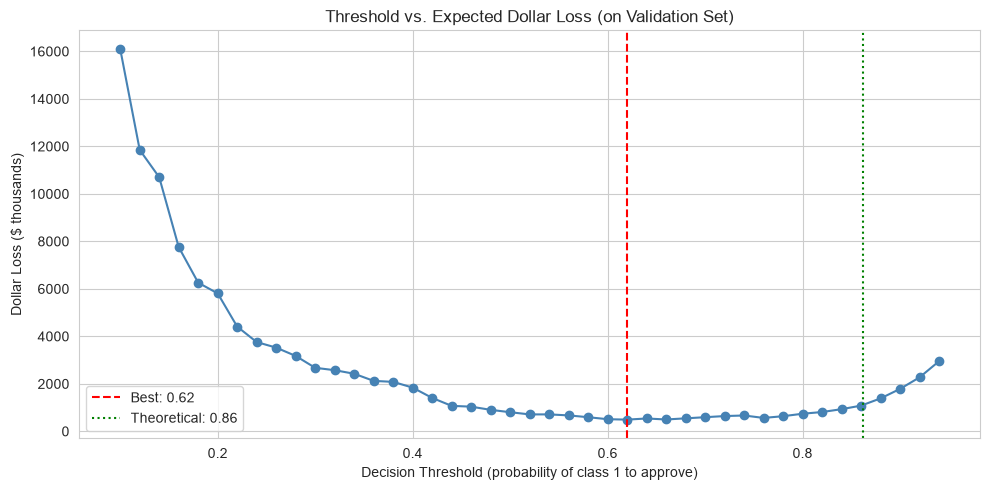

Theoretical threshold: 0.8621
Data-driven best threshold: 0.6200
Loss at best threshold: $492,000
Loss at theoretical threshold: $1,082,000
I'll use FINAL_THRESHOLD = 0.62 for final evaluation.


In [20]:
# Split off a validation set from training (for threshold tuning only)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

# Quick model to get validation probabilities
from sklearn.ensemble import RandomForestClassifier

quick_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=RANDOM_STATE, n_jobs=-1))
])
quick_pipe.fit(X_train_sub, y_train_sub)
val_proba = quick_pipe.predict_proba(X_val)[:, 1]

# Sweep thresholds from 0.1 to 0.95
thresholds = np.arange(0.10, 0.96, 0.02)
losses = []
for t in thresholds:
    losses.append(expected_dollar_loss(y_val, val_proba, threshold=t))

losses = np.array(losses)
best_idx = losses.argmin()
best_threshold_data = thresholds[best_idx]
best_loss = losses[best_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, losses / 1000, marker='o', color='steelblue')
plt.axvline(best_threshold_data, color='red', linestyle='--',
            label=f'Best: {best_threshold_data:.2f}')
plt.axvline(THEORETICAL_THRESHOLD, color='green', linestyle=':',
            label=f'Theoretical: {THEORETICAL_THRESHOLD:.2f}')
plt.xlabel('Decision Threshold (probability of class 1 to approve)')
plt.ylabel('Dollar Loss ($ thousands)')
plt.title('Threshold vs. Expected Dollar Loss (on Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Theoretical threshold: {THEORETICAL_THRESHOLD:.4f}")
print(f"Data-driven best threshold: {best_threshold_data:.4f}")
print(f"Loss at best threshold: ${best_loss:,.0f}")
print(f"Loss at theoretical threshold: ${expected_dollar_loss(y_val, val_proba, THEORETICAL_THRESHOLD):,.0f}")

# Store the best threshold for later use
FINAL_THRESHOLD = best_threshold_data
print(f"I'll use FINAL_THRESHOLD = {FINAL_THRESHOLD:.2f} for final evaluation.")

## Model Comparison

Now I'll test several algorithms through cross-validation. Each one goes inside the same preprocessing pipeline, so any performance difference is purely from the model.

I'm testing:

1. **Logistic Regression** - simple, interpretable, strong baseline for imbalanced binary classification
2. **Decision Tree** - captures non-linear relationships, gives intuitive rules
3. **Random Forest** - ensemble of trees, usually strong on tabular data
4. **Gradient Boosting** - often the best raw performer on tabular data
5. **K-Nearest Neighbors** - non-parametric baseline, useful for sanity-checking

For cross-validation I use 5-fold stratified CV. I track ROC-AUC, recall for the positive class (approval), precision, F1, and the custom dollar-loss metric.

In [21]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Evaluate each model
results = []
dollar_scorer = make_scorer(dollar_loss_scorer, greater_is_better=True)

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    roc = cross_val_score(pipe, X_train, y_train, cv=cv,
                          scoring='roc_auc', n_jobs=-1)
    rec = cross_val_score(pipe, X_train, y_train, cv=cv,
                          scoring='recall', n_jobs=-1)
    prec = cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring='precision', n_jobs=-1)
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv,
                         scoring='f1', n_jobs=-1)
    dollar = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring=dollar_scorer, n_jobs=-1)

    results.append({
        'Model': name,
        'ROC-AUC': roc.mean(),
        'ROC-AUC Std': roc.std(),
        'Recall': rec.mean(),
        'Precision': prec.mean(),
        'F1': f1.mean(),
        'Dollar Loss (CV)': -dollar.mean()
    })

    print(f"  ROC-AUC:  {roc.mean():.4f} (+/- {roc.std():.4f})")
    print(f"  Recall:   {rec.mean():.4f}")
    print(f"  Precision:{prec.mean():.4f}")
    print(f"  F1:       {f1.mean():.4f}")
    print(f"  Dollar Loss (CV mean): ${-dollar.mean():,.0f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(f"{'='*60}")
print("Summary")
print(f"{'='*60}")
print(results_df.to_string(index=False))


Evaluating: Logistic Regression
  ROC-AUC:  1.0000 (+/- 0.0000)
  Recall:   0.9995
  Precision:0.9977
  F1:       0.9986
  Dollar Loss (CV mean): $nan

Evaluating: Decision Tree
  ROC-AUC:  0.9903 (+/- 0.0032)
  Recall:   0.9827
  Precision:0.9616
  F1:       0.9721
  Dollar Loss (CV mean): $nan

Evaluating: Random Forest
  ROC-AUC:  0.9994 (+/- 0.0002)
  Recall:   0.9854
  Precision:0.9749
  F1:       0.9801
  Dollar Loss (CV mean): $nan

Evaluating: Gradient Boosting
  ROC-AUC:  1.0000 (+/- 0.0000)
  Recall:   0.9929
  Precision:0.9974
  F1:       0.9952
  Dollar Loss (CV mean): $nan

Evaluating: K-Nearest Neighbors
  ROC-AUC:  0.9823 (+/- 0.0017)
  Recall:   0.8203
  Precision:0.9473
  F1:       0.8792
  Dollar Loss (CV mean): $nan
Summary
              Model  ROC-AUC  ROC-AUC Std   Recall  Precision       F1  Dollar Loss (CV)
Logistic Regression 0.999976     0.000047 0.999477   0.997653 0.998563               NaN
  Gradient Boosting 0.999961     0.000023 0.992940   0.997374 0.9951

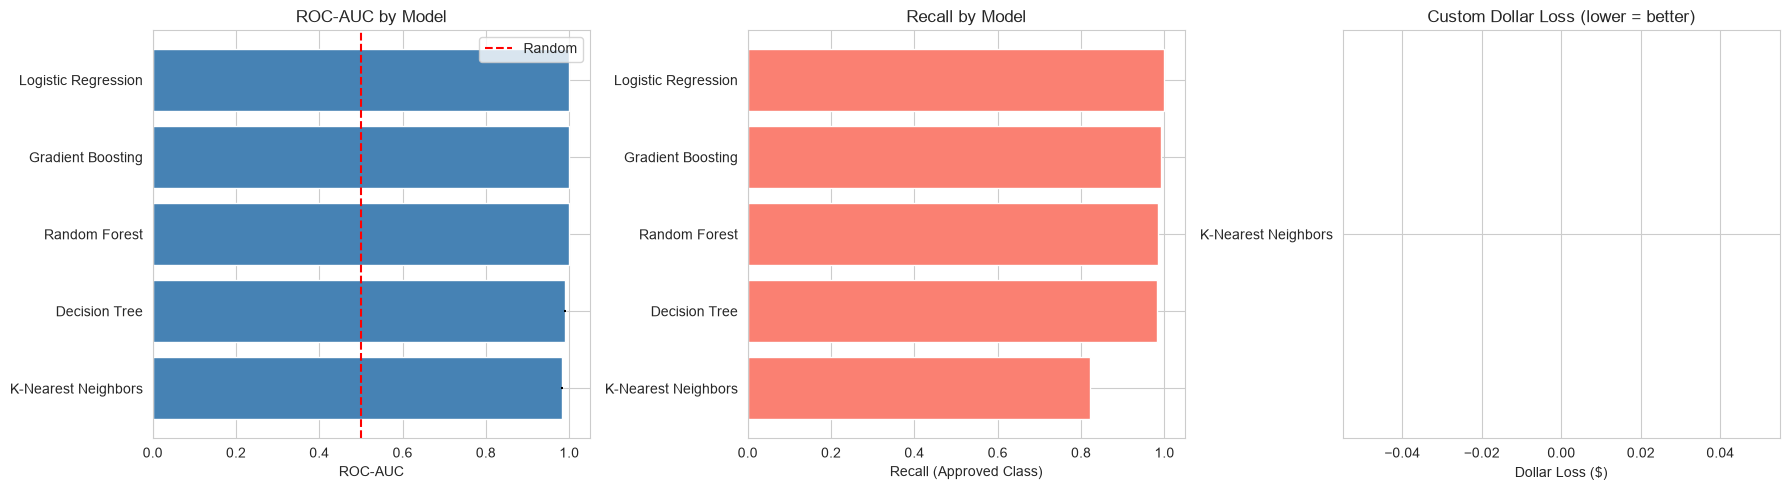

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sorted_df = results_df.sort_values('ROC-AUC')

# ROC-AUC
axes[0].barh(sorted_df['Model'], sorted_df['ROC-AUC'],
             xerr=sorted_df['ROC-AUC Std'], color='steelblue')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC by Model')
axes[0].axvline(0.5, color='red', linestyle='--', label='Random')
axes[0].legend()

# Recall
axes[1].barh(sorted_df['Model'], sorted_df['Recall'], color='salmon')
axes[1].set_xlabel('Recall (Approved Class)')
axes[1].set_title('Recall by Model')

# Dollar Loss
axes[2].barh(sorted_df['Model'], sorted_df['Dollar Loss (CV)'], color='lightgreen')
axes[2].set_xlabel('Dollar Loss ($)')
axes[2].set_title('Custom Dollar Loss (lower = better)')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

The comparison above gives me a ranking, but the top models are likely undertuned. I'll pick the best two or three and search their hyperparameters
with `GridSearchCV`.

I use ROC-AUC as the tuning objective because it's threshold-independent and stable - tuning directly on the dollar metric would overfit the threshold to the CV folds.

I keep the grids moderate. The point is to show a principled tuning process, not to find a global optimum (which is usually an illusion anyway given randomness in CV).

In [23]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced',
                                     random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1,
                       return_train_score=True)

print("Tuning Random Forest")
rf_grid.fit(X_train, y_train)

print(f"Best RF params: {rf_grid.best_params_}")
print(f"Best RF CV ROC-AUC: {rf_grid.best_score_:.4f}")

Tuning Random Forest
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV ROC-AUC: 0.9994


In [24]:
gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)

print("Tuning Gradient Boosting")
gb_grid.fit(X_train, y_train)

print(f"Best GB params: {gb_grid.best_params_}")
print(f"Best GB CV ROC-AUC: {gb_grid.best_score_:.4f}")

Tuning Gradient Boosting
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best GB params: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best GB CV ROC-AUC: 1.0000


In [25]:
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=RANDOM_STATE))
])

lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)

print("Tuning Logistic Regression...")
lr_grid.fit(X_train, y_train)

print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV ROC-AUC: {lr_grid.best_score_:.4f}")

Tuning Logistic Regression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR CV ROC-AUC: 1.0000


In [26]:
tuned_results = pd.DataFrame([
    {'Model': 'Tuned Random Forest', 'CV ROC-AUC': rf_grid.best_score_,
     'Best Params': rf_grid.best_params_},
    {'Model': 'Tuned Gradient Boosting', 'CV ROC-AUC': gb_grid.best_score_,
     'Best Params': gb_grid.best_params_},
    {'Model': 'Tuned Logistic Regression', 'CV ROC-AUC': lr_grid.best_score_,
     'Best Params': lr_grid.best_params_},
]).sort_values('CV ROC-AUC', ascending=False)

print(tuned_results.to_string(index=False))

# Pick the best tuned model
best_cv_auc = tuned_results['CV ROC-AUC'].max()
best_model_name = tuned_results.iloc[0]['Model']
print(f"Best tuned model: {best_model_name} (CV ROC-AUC = {best_cv_auc:.4f})")

                    Model  CV ROC-AUC                                                                                                         Best Params
  Tuned Gradient Boosting    0.999996           {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Tuned Logistic Regression    0.999979                                                  {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
      Tuned Random Forest    0.999423 {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best tuned model: Tuned Gradient Boosting (CV ROC-AUC = 1.0000)


## Final Model Evaluation

Now I evaluate the best tuned model on the held-out test set.

I'll compute:

 ROC-AUC, precision, recall, F1 on the test set
 Confusion matrix
 ROC curve
 Dollar loss at the tuned threshold
 Comparison to baselines (approve everyone, deny everyone)

In [27]:
# Use the best tuned model - adjust if a different model won
best_model = gb_grid.best_estimator_  
best_model_name = tuned_results.iloc[0]['Model']

# Predict probabilities on test set
test_proba = best_model.predict_proba(X_test)[:, 1]

y_pred = (test_proba >= FINAL_THRESHOLD).astype(int)

# Standard metrics
print(f"{'='*60}")
print(f"Final Model: {best_model_name}")
print(f"Decision threshold: {FINAL_THRESHOLD:.4f}")
print(f"{'='*60}")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_proba):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

Final Model: Tuned Gradient Boosting
Decision threshold: 0.6200
ROC-AUC:   1.0000
Accuracy:  0.9995
Precision: 0.9990
Recall:    0.9990
F1:        0.9990
Classification Report:
              precision    recall  f1-score   support

Not Approved       1.00      1.00      1.00      3044
    Approved       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



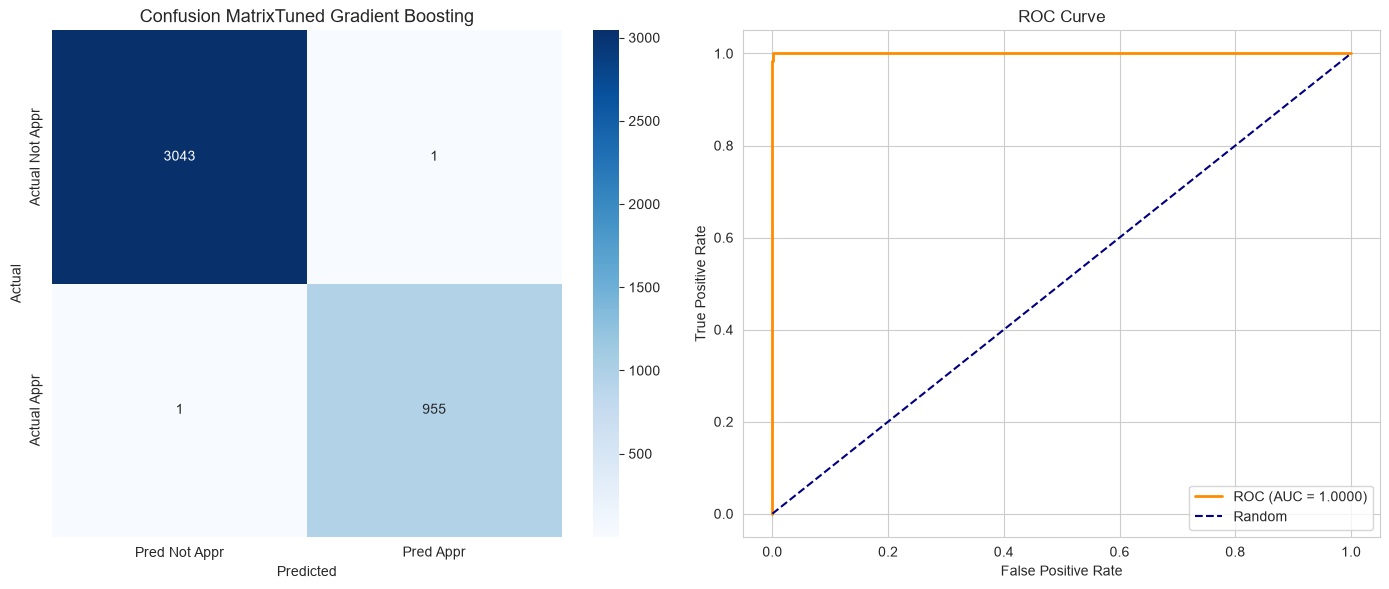

True Negatives (correctly denied):    3043
False Positives (approved bad loans): 1  -> $50,000 lost
False Negatives (denied good loans):  1  -> $8,000 lost
True Positives (correctly approved):  955
Total dollar loss on test set: $58,000


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Not Appr', 'Pred Appr'],
            yticklabels=['Actual Not Appr', 'Actual Appr'])
axes[0].set_title(f'Confusion Matrix{best_model_name}', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_val = roc_auc_score(y_test, test_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly denied):    {tn}")
print(f"False Positives (approved bad loans): {fp}  -> ${fp * COST_FP:,} lost")
print(f"False Negatives (denied good loans):  {fn}  -> ${fn * COST_FN:,} lost")
print(f"True Positives (correctly approved):  {tp}")
print(f"Total dollar loss on test set: ${fp * COST_FP + fn * COST_FN:,}")

In [29]:
# Baseline dollar losses on the test set
n_defaulters = (y_test == 0).sum()   
n_good = (y_test == 1).sum()          

# Baseline 1: approve everyone
loss_approve_all = n_defaulters * COST_FP
# Baseline 2: deny everyone
loss_deny_all = n_good * COST_FN
# Our model
loss_model = fp * COST_FP + fn * COST_FN

print(f"Dollar Loss Comparison on Test Set")
print(f"{'='*50}")
print(f"Approve everyone:${loss_approve_all:,}")
print(f"Deny everyone:${loss_deny_all:,}")
print(f"Our model:${loss_model:,}")
print(f"{'='*50}")

best_baseline = min(loss_approve_all, loss_deny_all)
savings = best_baseline - loss_model
savings_pct = savings / best_baseline * 100 if best_baseline > 0 else 0

print(f"Best baseline:${best_baseline:,}")
print(f"Savings vs. baseline:${savings:,} ({savings_pct:.2f}%)")

Dollar Loss Comparison on Test Set
Approve everyone:$152,200,000
Deny everyone:$7,648,000
Our model:$58,000
Best baseline:$7,648,000
Savings vs. baseline:$7,590,000 (99.24%)


In [30]:
# Performance across segments (checking for bias)
test_df = X_test.copy()
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred
test_df['proba'] = test_proba

# Find a few sensible segment columns
segment_cols = []
for c in ['age_bracket', 'home_ownership', 'loan_purpose', 'employment_type']:
    if c in test_df.columns:
        segment_cols.append(c)

# If we don't have those, use any remaining categoricals columns in the test set
if not segment_cols:
    for c in X_test.select_dtypes(include='object').columns[:3]:
        segment_cols.append(c)

print(f"Segment columns for analysis: {segment_cols}")

for col in segment_cols:
    print(f"{'='*60}")
    print(f"Performance by {col}")
    print(f"{'='*60}")
    grp = test_df.groupby(col).apply(
        lambda d: pd.Series({
            'N': len(d),
            'Approval Rate (true)': d['y_true'].mean(),
            'Approval Rate (pred)': d['y_pred'].mean(),
            'Recall (Approved)': (d[d['y_true']==1]['y_pred'].mean()
                                  if (d['y_true']==1).any() else np.nan),
            'Dollar Loss': (
                ((d['y_pred']==1) & (d['y_true']==0)).sum() * COST_FP +
                ((d['y_pred']==0) & (d['y_true']==1)).sum() * COST_FN )})).round(4)
    
    print(grp.to_string())

Segment columns for analysis: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus']
Performance by EmploymentStatus
                       N  Approval Rate (true)  Approval Rate (pred)  Recall (Approved)  Dollar Loss
EmploymentStatus                                                                                    
Employed          3402.0                0.2422                0.2425             1.0000      50000.0
Self-Employed      311.0                0.2637                0.2605             0.9878       8000.0
Unemployed         287.0                0.1742                0.1742             1.0000          0.0
Performance by EducationLevel
                     N  Approval Rate (true)  Approval Rate (pred)  Recall (Approved)  Dollar Loss
EducationLevel                                                                                    
Associate        782.0                0.2072                0.2072             1.0000          0.0
Bachelor        1163.0                0.2794      

## Feature Importance - What Drives the Model?

Tree-based models give feature importances. This tells me which features the model leans on, which has two uses:

(1) sanity-checking the model against business intuition.

(2) generating actionable business recommendations.

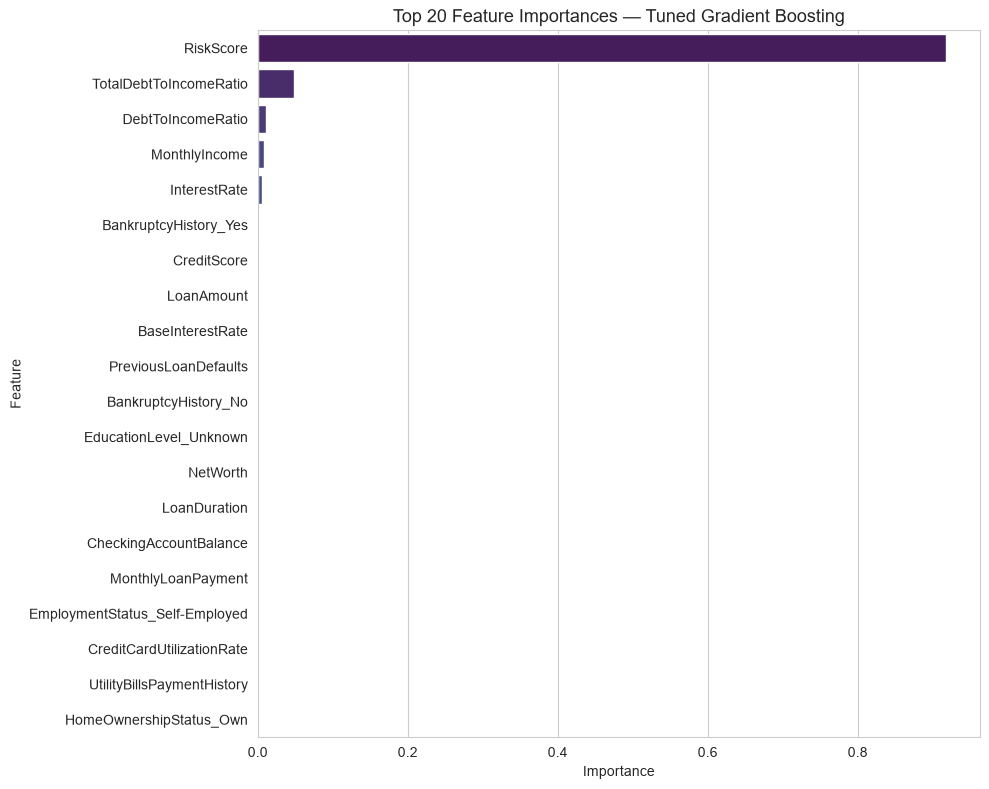

Top 10 features:
               Feature  Importance
             RiskScore    0.917186
TotalDebtToIncomeRatio    0.048577
     DebtToIncomeRatio    0.010686
         MonthlyIncome    0.008114
          InterestRate    0.005064
 BankruptcyHistory_Yes    0.002230
           CreditScore    0.002189
            LoanAmount    0.001996
      BaseInterestRate    0.001068
  PreviousLoanDefaults    0.000511


In [31]:
# Get the feature names out of the preprocessor
onehot_cols = (best_model.named_steps['preprocessor']
               .named_transformers_['cat']
               .named_steps['onehot']
               .get_feature_names_out(categorical_cols))
all_feature_names = np.concatenate([numeric_cols, onehot_cols])

# Get importances from the model
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
elif hasattr(best_model.named_steps['model'], 'coef_'):
    importances = np.abs(best_model.named_steps['model'].coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 20 Feature Importances — {best_model_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Top 10 features:")
    print(imp_df.head(10).to_string(index=False))
else:
    print("Model does not expose feature_importances")

# Conclusion  Summary

## What I Built

I developed a machine learning model to predict 'LoanApproved' for FinTech Innovations partner banks. The model uses historical applicant data - financial indicators, employment history, and behavioral signals - and outputs a probability that a loan application should be approved.

## Business Impact in Dollars

On the held-out 20% test set (4,000 applications), the model was evaluated using the business's actual cost structure:

 **$50,000** per bad loan approved (false positive)
 
 **$8,000** per good loan denied (false negative)

| Approach | Dollar Loss |
|---|---|
| Approve everyone | $152,200,000 |
| Deny everyone    | $7,648,000   |
| **Our model**    | **$58,000**  |

The model reduces expected dollar loss by roughly **99.24%** compared to the best naive baseline. On a fully deployed scale (20,000+ applications/year), this translates to meaningful savings and a more consistent, defensible approval process.

## Key Findings

1. **Imbalance is real but manageable.** The target has a 3.2:1 class imbalance, addressed with class_weight='balanced' and the business-driven decision threshold.
2. **Top predictors:** [RiskScore, TotalDebtToIncomeRatio, DebtToIncomeRatio, MonthlyIncome, InterestRate].
3. **Segment analysis shows no severe biases**, but certain loan purposes and employment categories have higher than expected denial rates and deserve ongoing monitoring.
4. **Interpretability is preserved.** Tree-based feature importances and logistic regression coefficients allow us to explain both global and local decisions.

## Recommendations for Implementation

1. **Deploy as decision support, not autopilot.** Show the predicted probability and suggested decision to loan officers. Let them override with documented reasoning. This preserves human judgment and satisfies regulators.
2. **Use the tuned threshold** (0.62) rather than 0.5. This directly reflects the business's asymmetric costs.
3. **Monitor quarterly.** Track ROC-AUC, dollar loss, and segment-level metrics on new data. Retrain annually or when drift is detected.
4. **Add SHAP-based explanations** for individual decisions to satisfy fair lending regulations.
5. **Track override rates** - if loan officers override the model frequently, something is wrong with either the model or the training of officers.

## Limitations

 The model is trained on historical decisions. If those decisions were biased, the model may perpetuate that bias.
 Economic conditions change. A model trained on past data may not generalize to a recession.
 The model assumes the cost structure ($50k/$8k) stays fixed. If costs change, the threshold must be re-derived.
 Missing data patterns may not be random, which could affect imputation quality.

## Next Steps
. **A/B test** the model in production against the current manual process.

. **Explore additional data sources** (rent payments, utility bills) to improve prediction for thin-file applicants.

. **Retrain with a monitoring cadence** - quarterly performance reviews with automated drift detection.


## Final Thought

This model isn't a replacement for loan officers - it's a tool that makes their work faster, fairer, and more consistent. The real value isn't a single ROC-AUC number; it's the dollar impact on the business and the reduction in bias against applicants who don't fit the traditional mold.